Particles of interest: 101 (ejected), 104 (collided w/ Sun), 106 (collided w/ Sun). 

In [26]:
# Setup

import rebound
import numpy as np
import matplotlib.pyplot as plt
from rebound import hash as h

interest = [101, 104, 106]
crash = [104, 106]
eject = [101]

MONITOR SIMULATION AS IT RUNS

In [2]:
# Import simulation archive

sa = rebound.Simulationarchive("outputs/orbital_integration/archive.bin")

print("Number of snapshots: {}".format(len(sa)))
print("Time of first and last snapshot: {:.1f}, {:.1f}".format(sa.tmin, sa.tmax))

N_pl = 8 # Total number of bodies
N_tp = 15 # Number of test particles

Number of snapshots: 9195
Time of first and last snapshot: 0.0, 9194000.0


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\rebound\simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


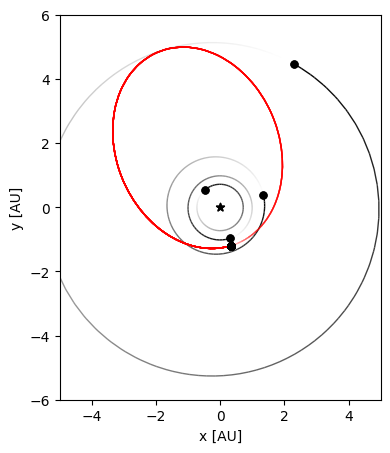

In [3]:
# Earliest snapshot in simulation

sim = sa[0]
rebound.OrbitPlot(sim, unitlabel = "[AU]", xlim = [-5, 5], ylim = [-6, 6],
                  color = (N_pl - 1) * ["black"] + N_tp * ["red"])

---------------------------------
REBOUND version:     	4.4.2
REBOUND built on:    	Jul 15 2024 18:47:33
Number of particles: 	9
Selected integrator: 	mercurius
Simulation time:     	9.1940000046221409e+06
Current timestep:    	0.024608
---------------------------------
<rebound.particle.Particle object at 0x15c1a65dcd0, m=0.9999999999950272 x=0.004855807686783313 y=0.0004183092724011272 z=-9.656208491604247e-05 vx=-0.0010808483727913743 vy=0.002508126434973679 vz=1.3679103798233664e-05>
<rebound.particle.Particle object at 0x15c1a65f4d0, m=2.447838287784771e-06 x=-0.487884343534067 y=-0.5428257312387478 z=0.009654707864980476 vx=5.192464428189059 vy=-5.102388566576229 vz=-0.1843002652606489>
<rebound.particle.Particle object at 0x15c1a65dcd0, m=3.0404326489511185e-06 x=-0.7431064457322916 y=-0.6474340293510514 z=0.04757264440840366 vx=4.000724282622523 vy=-4.91411067535351 vz=-0.18229117501894718>
<rebound.particle.Particle object at 0x15c1a65f4d0, m=3.2271560828978514e-07 x=0.3819001

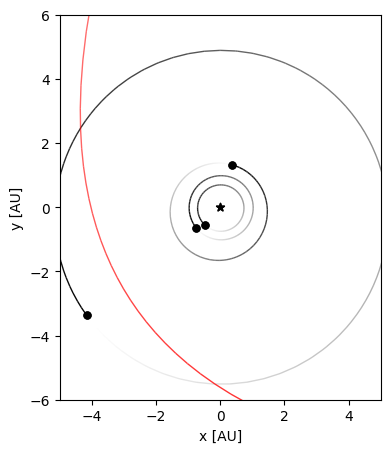

In [4]:
# Latest snapshot

sim = sa[-1]
rebound.OrbitPlot(sim, unitlabel = "[AU]", xlim = [-5, 5], ylim = [-6, 6],
                  color = (N_pl - 1) * ["black"] + N_tp * ["red"])
sim.status()

In [5]:
# Convert values into osculating orbital elements

orbits = sim.orbits()
for orbit in orbits:
    print(orbit)

<rebound.Orbit instance, a=0.723349459830615 e=0.04213465140697396 inc=0.029072584139036076 Omega=1.3089481087581556 omega=0.7172633713764656 f=1.949318561723416>
<rebound.Orbit instance, a=0.9999987440289988 e=0.03063657551709324 inc=0.05682091707985579 Omega=1.7239400410397085 omega=0.8399813706757362 f=1.2907431720355342>
<rebound.Orbit instance, a=1.523665777867575 e=0.09796647532993537 inc=0.095006431731805 Omega=0.5480809684248336 omega=0.6872535742458972 f=0.05926550069704195>
<rebound.Orbit instance, a=5.201754029505751 e=0.06059617323244308 inc=0.02569935858521763 Omega=1.6259066811172942 omega=0.04813525994730572 f=2.146613535520487>
<rebound.Orbit instance, a=9.550374475492124 e=0.018876169995638886 inc=0.04014867016569808 Omega=2.143677297267144 omega=1.6411771588123036 f=4.933359412176708>
<rebound.Orbit instance, a=19.192927484420643 e=0.011923451533576695 inc=0.019829007098868076 Omega=2.631112134700199 omega=3.3382241725638884 f=2.27973041908189>
<rebound.Orbit instance

EXTRACT INFORMATION ABOUT A SINGLE PARTICLE

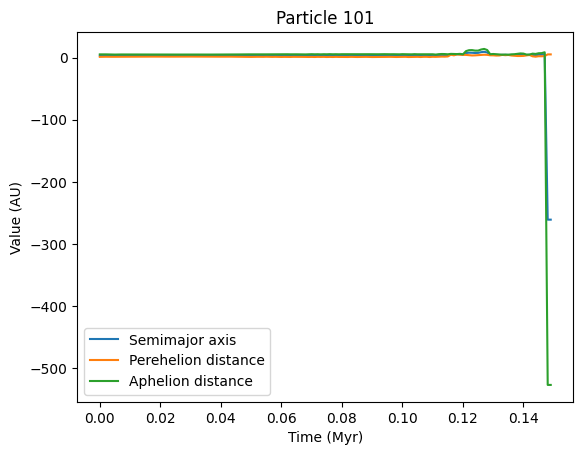

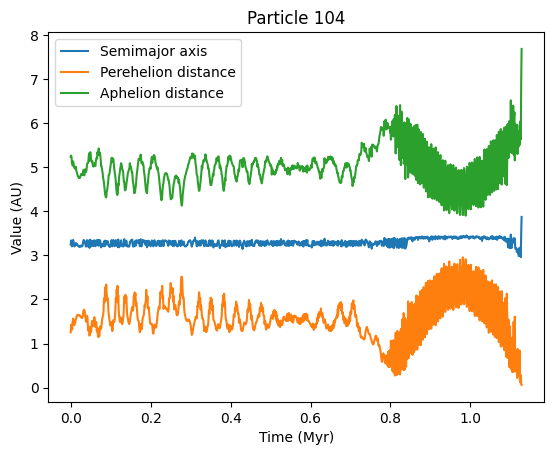

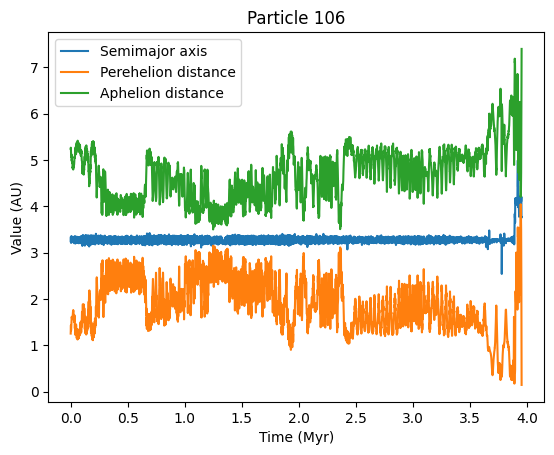

In [6]:
# a, q, Q plots for particles of interest

for pid in interest:

    t = np.zeros(len(sa))
    a = np.zeros(len(sa))
    e = np.zeros(len(sa))

    for i, sim in enumerate(sa):
        t[i] = sim.t / 1e6
        try:
            a[i] = sim.particles[h(pid)].a
            e[i] = sim.particles[h(pid)].e
        except rebound.ParticleNotFound: # Particle ejected
            a = a[:i]
            e = e[:i]
            t = t[:i]
            break

    # Add perehelion distance (q), aphelion distance (Q) to plot
    q = a * (1 - e)
    Q = a * (1 + e)

    plt.plot(t, a, label = "Semimajor axis")
    plt.plot(t, q, label = "Perehelion distance")
    plt.plot(t, Q, label = "Aphelion distance")
    plt.xlabel("Time (Myr)")
    plt.ylabel("Value (AU)")
    plt.title("Particle {0}".format(pid))
    plt.legend()
    plt.show()

MAKE A MOVIE OF PARTICLE'S ORBIT

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\rebound\simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


104 0
104 10
104 20
104 30
104 40
104 50
104 60
104 70
104 80
104 90
104 100
104 110
104 120
104 130
104 140
104 150
104 160
104 170
104 180
104 190
104 200
104 210
104 220
104 230
104 240
104 250
104 260
104 270
104 280
104 290
104 300
104 310
104 320
104 330
104 340
104 350
104 360
104 370
104 380
104 390
104 400
104 410
104 420
104 430
104 440
104 450
104 460
104 470
104 480
104 490
104 500
104 510
104 520
104 530
104 540
104 550
104 560
104 570
104 580
104 590
104 600
104 610
104 620
104 630
104 640
104 650
104 660
104 670
104 680
104 690
104 700
104 710
104 720
104 730
104 740
104 750
104 760
104 770
104 780
104 790
104 800
104 810
104 820
104 830
104 840
104 850
104 860
104 870
104 880
104 890
104 900
104 910
104 920
104 930
104 940
104 950
104 960
104 970
104 980
104 990
104 1000
104 1010
104 1020
104 1030
104 1040
104 1050
104 1060
104 1070
104 1080
104 1090
104 1100
104 1110
104 1120
104 1130
104 1140
104 1150
104 1160
104 1170
104 1180
104 1190
104 1200
104 1210
104 1220
104 

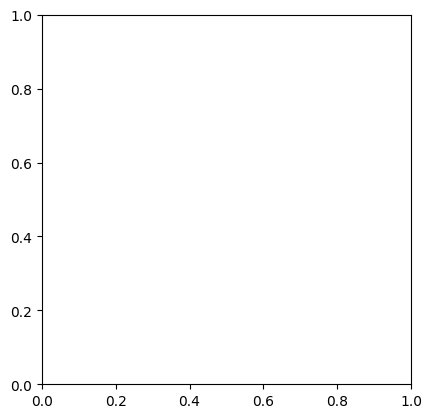

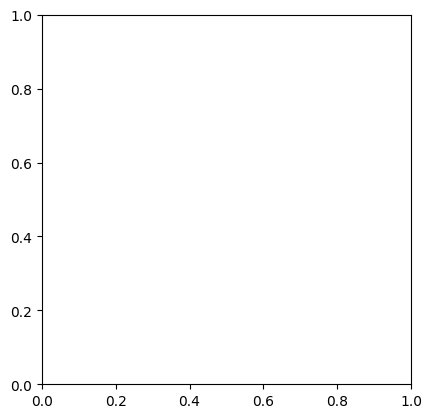

In [27]:
# Make movie of orbit's evolution from top-down perspective
# No idea why it's printing three blank frames

for pid in crash:

    count = 0 # Number frames consecutively
    fig, ax = plt.subplots()

    for i, sim in enumerate(sa):
        if i % 10: # Only plot every stepsize-th frame
            continue

        print(pid, i)
        try:
            op1 = rebound.OrbitPlot(sim, fig = fig, ax = ax, orbit_style = "solid",
                                    lw = 1, particles = [1, 2, 3, 4, 5, 6, 7])
            op1.particles.set_sizes([0])

            op2 = rebound.OrbitPlot(sim, fig = op1.fig, ax = op1.ax, 
                                    orbit_style = "solid", lw = 1, 
                                    particles = [h(pid)], color = "red")
            op2.particles.set_sizes([0])

            ax.set_aspect("equal")
            ax.set_xlim(-8, 8)
            ax.set_ylim(-8, 8)
            ax.set_xlabel("x [AU]")
            ax.set_ylabel("y [AU]")

            ax.set_title("Particle {0}".format(pid))
            ax.text(-4, -7, "t = {:4.1f} Myr".format(sim.t / 1e6))
            fig.savefig("outputs/orbital_integration/movie/{}/frame_{:04d}.png".format(pid, count))
            
            count += 1
            ax.clear()
        except rebound.ParticleNotFound:
            break
        


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\rebound\simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


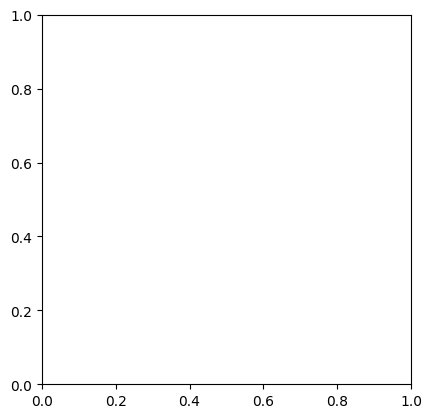

In [23]:
# Plot 101 in high resolution
sa = rebound.Simulationarchive("outputs/orbital_integration/archive_101.bin")

for pid in [101]:

    count = 0 # Number frames consecutively
    fig, ax = plt.subplots()

    for i, sim in enumerate(sa):
        if i % 100:
            continue
        
        try:
            op1 = rebound.OrbitPlot(sim, fig = fig, ax = ax, orbit_style = "solid",
                                    lw = 1, particles = [1, 2, 3, 4, 5, 6, 7])
            op1.particles.set_sizes([0])

            op2 = rebound.OrbitPlot(sim, fig = op1.fig, ax = op1.ax, 
                                    orbit_style = "solid", lw = 1, 
                                    particles = [h(pid)], color = "red")
            op2.particles.set_sizes([0])

            ax.set_aspect("equal")
            ax.set_xlim(-8, 8)
            ax.set_ylim(-8, 8)
            ax.set_xlabel("x [AU]")
            ax.set_ylabel("y [AU]")

            ax.set_title("Particle {0}".format(pid))
            ax.text(-4, -7, "t = {:4.1f} Myr".format(sim.t / 1e6))
            fig.savefig("outputs/orbital_integration/movie/{}_highres/frame_{:04d}.png".format(pid, count))
            
            count += 1
            ax.clear()
        except rebound.ParticleNotFound:
            break

RESIDENCE PLOT SHOWING HOW THE SEMIMAJOR AXIS AND ECCENTRICITY OF CLONES CHANGE OVER TIME
(Started copy-pasting from PDF here so the code looks kind of bad)
(Don't bother using the code below here for now)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\rebound\simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


Stopped at i = 150
Stopped at i = 151
Stopped at i = 152
Stopped at i = 153
Stopped at i = 154
Stopped at i = 155
Stopped at i = 156
Stopped at i = 157
Stopped at i = 158
Stopped at i = 159
Stopped at i = 160
Stopped at i = 161
Stopped at i = 162
Stopped at i = 163
Stopped at i = 164
Stopped at i = 165
Stopped at i = 166
Stopped at i = 167
Stopped at i = 168
Stopped at i = 169
Stopped at i = 170
Stopped at i = 171
Stopped at i = 172
Stopped at i = 173
Stopped at i = 174
Stopped at i = 175
Stopped at i = 176
Stopped at i = 177
Stopped at i = 178
Stopped at i = 179
Stopped at i = 180
Stopped at i = 181
Stopped at i = 182
Stopped at i = 183
Stopped at i = 184
Stopped at i = 185
Stopped at i = 186
Stopped at i = 187
Stopped at i = 188
Stopped at i = 189
Stopped at i = 190
Stopped at i = 191
Stopped at i = 192
Stopped at i = 193
Stopped at i = 194
Stopped at i = 195
Stopped at i = 196
Stopped at i = 197
Stopped at i = 198
Stopped at i = 199
Stopped at i = 200
Stopped at i = 201
Stopped at i

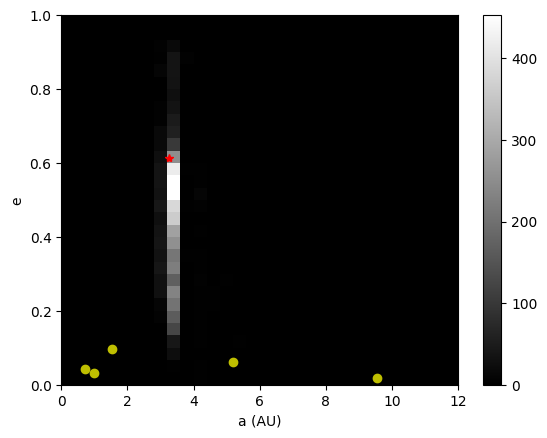

In [18]:
# Semimajor axis and eccentricity of every clone at every time step
sa = rebound.Simulationarchive("outputs/orbital_integration/archive.bin")

a_all = []
e_all = []

for i, sim in enumerate(sa):
    for pid in interest:
        try:
            a_all.append(sim.particles[h(pid)].a)
            e_all.append(sim.particles[h(pid)].e)
        except rebound.ParticleNotFound:
            continue # Continue on with the next clone


amin, amax = 0, 12
emin, emax = 0, 1
h2d,xedge,yedge,im = plt.hist2d(a_all, e_all, range=[[amin,amax],[emin,emax]], bins=(30, 30))
plt.xlabel("a (AU)")
plt.ylabel("e")

plt.colorbar()

# Initial position
a_init = 3.245761552052847
e_init = 0.6141866747698732
plt.plot(a_init,e_init,"*",color="r")

# plt.show()

# Loop over every snapshot and every test particle
sim = sa[-1]
a_tp = []
e_tp = []
for pid in interest:
    try:
        a_tp.append(sim.particles[h(pid)].a)
        e_tp.append(sim.particles[h(pid)].e)
    except:
        continue

plt.plot(a_tp,e_tp,"co")

# Add planets
a_pl = []
e_pl = []
for id in range(1,N_pl):
    a_pl.append(sim.particles[id].a)
    e_pl.append(sim.particles[id].e)
plt.plot(a_pl,e_pl,"yo")
plt.gray()
plt.show()